<a href="https://colab.research.google.com/github/Ebasurtos/AHPC/blob/main/proyecto_HPC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Ebasurtos/AHPC/blob/main/Proyecto_AHPC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto AHPC**

**Integrantes:**

*   Jorge Luis Palacios Chilo
*   Eder Basurto Siuce

**Importamos Librerias**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

**Cargamos drive de Google**

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


**Cargamos datos del Drive**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Ciclo IV/AHPC/Data_AHPC.csv', sep=';')
df['time'] = df['t_comp'] + df['t_comm']
df.head()

,#Job,N_dim,n_mpi,t_comp,t_comm,time
0,22598_1,80,1,0.2058,0.00049,0.20629
1,22598_2,160,1,0.4915,0.01014,0.50164
2,22598_3,240,1,0.6978,0.02795,0.72575
3,22598_4,320,1,1.0873,0.04751,1.13481
4,22598_5,512,1,1.7702,0.05570,1.82590


**Creamos el grafico de Tiempos vs procesos**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


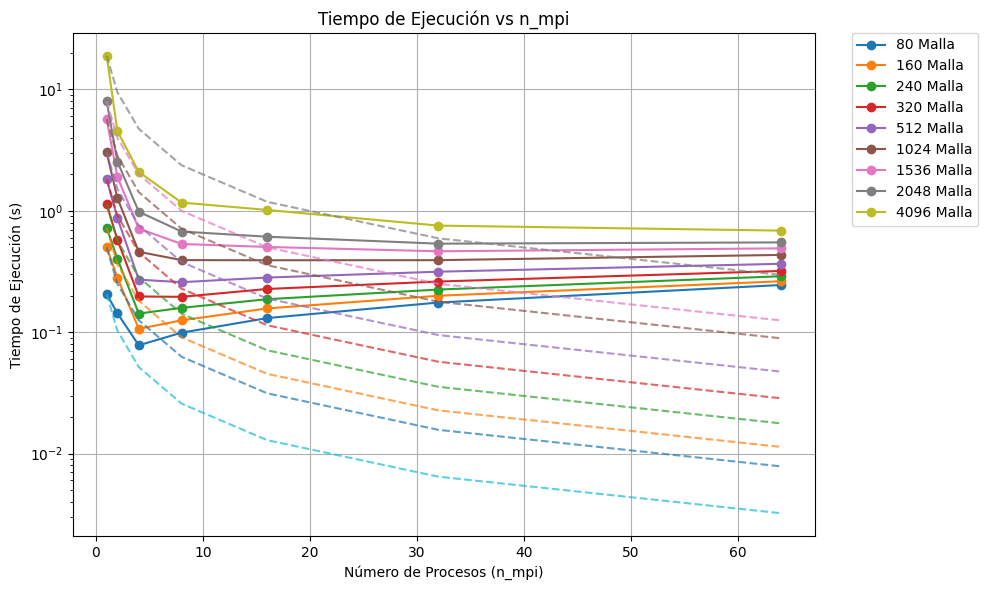

In [ ]:
# Crear la figura y ejes ANTES de graficar
fig, axes = plt.subplots(1, 1, figsize=(10, 6))  # Si solo quieres un subplot
# O si quieres mantener la estructura con múltiples subplots:
# fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Tu código de graficación (modificado para usar axes en lugar de axes[0])
for samples in df['N_dim'].unique():
    subset = df[df['N_dim'] == samples]
    axes.plot(subset['n_mpi'], subset['time'], marker='o', label=f'{samples} Malla')

# Agregar línea teórica T = 1/p
n_jobs_range = df['n_mpi'].unique()
n_jobs_range_sorted = np.sort(n_jobs_range)

# Para cada tamaño de muestra, calcular y graficar la línea teórica
for samples in df['N_dim'].unique():
    subset = df[df['N_dim'] == samples]
    t1 = subset[subset['n_mpi'] == 1]['time'].iloc[0]  # Tiempo con 1 worker
    theoretical_times = t1 / n_jobs_range_sorted  # T = T1 / p
    axes.plot(n_jobs_range_sorted, theoretical_times, '--', alpha=0.7)

axes.set_xlabel('Número de Procesos (n_mpi)')
axes.set_ylabel('Tiempo de Ejecución (s)')
axes.set_yscale('log')
axes.set_title('Tiempo de Ejecución vs n_mpi')
axes.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
axes.grid(True)

# Mostrar la gráfica
plt.tight_layout()
plt.show()

**Calculamos el Sppedup y Eficiencia**

In [ ]:
# Calcular speedup y eficiencia para cada N_dim (Mallas)
results = []
for samples in df['N_dim'].unique():
    subset = df[df['N_dim'] == samples].sort_values('n_mpi')
    t1 = subset[subset['n_mpi'] == 1]['time']
    if not t1.empty:
        t1 = t1.iloc[0]
        subset = subset.copy()
        subset['speedup'] = t1 / subset['time']
        subset['efficiency'] = subset['speedup'] / subset['n_mpi']
        results.append(subset)

result_df = pd.concat(results)

**Creamos a grafica de Speedup vs n_mpi**

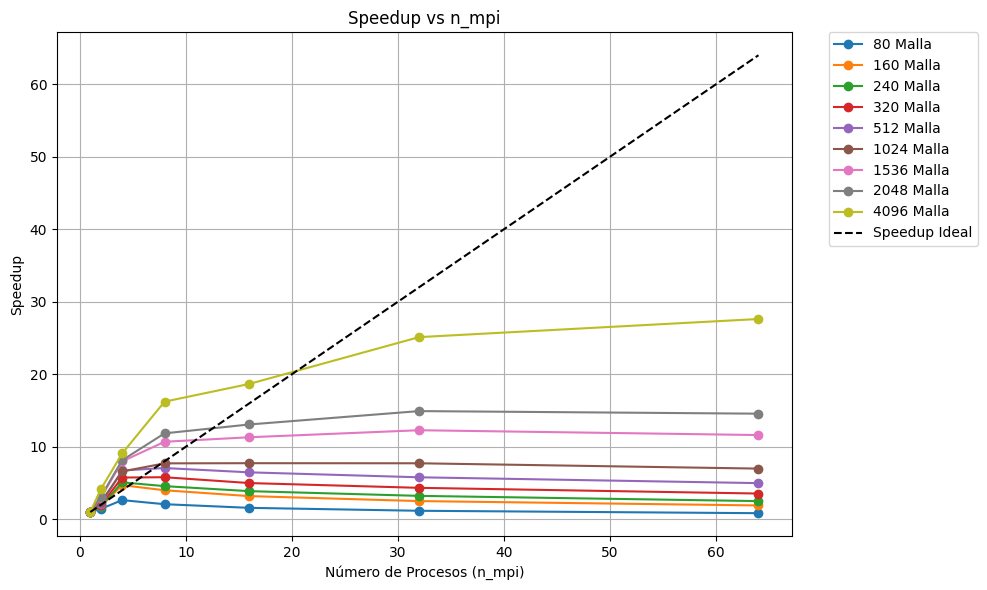

In [ ]:
# Crear la figura y ejes ANTES de graficar
fig, axes = plt.subplots(1, 1, figsize=(10, 6))  # Si solo quieres un subplot
# Tu código de graficación (modificado para usar axes en lugar de axes[0])
for samples in result_df['N_dim'].unique():
    subset = result_df[result_df['N_dim'] == samples]
    axes.plot(subset['n_mpi'], subset['speedup'], marker='o', label=f'{samples} Malla')

n_jobs_range = np.sort(result_df['n_mpi'].unique())
axes.plot(n_jobs_range, n_jobs_range, 'k--', label='Speedup Ideal')

axes.set_xlabel('Número de Procesos (n_mpi)')
axes.set_ylabel('Speedup')
#axes.set_yscale('log')
axes.set_title('Speedup vs n_mpi')
axes.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
axes.grid(True)

# Mostrar la gráfica
plt.tight_layout()
plt.show()

**Creamos el gráfico de Eficiencia vs n_mpi**

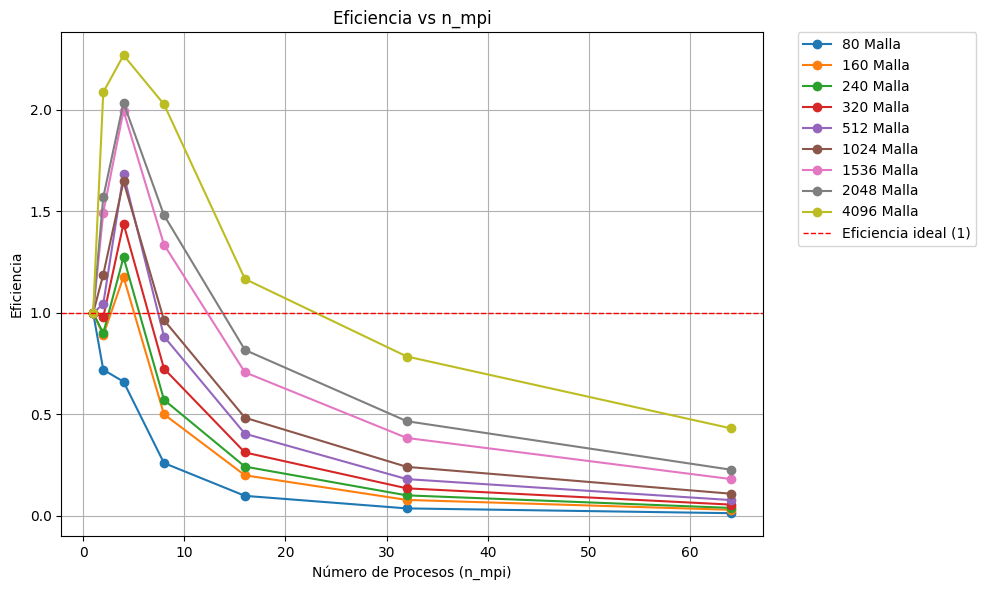

In [ ]:
# Crear la figura y ejes ANTES de graficar
fig, axes = plt.subplots(1, 1, figsize=(10, 6))  # Si solo quieres un subplot
# Tu código de graficación (modificado para usar axes en lugar de axes[0])
for samples in result_df['N_dim'].unique():
    subset = result_df[result_df['N_dim'] == samples]
    axes.plot(subset['n_mpi'], subset['efficiency'], marker='o', label=f'{samples} Malla')

# Añadir línea horizontal en y=1
axes.axhline(y=1, color='r', linestyle='--', linewidth=1, label='Eficiencia ideal (1)')

axes.set_xlabel('Número de Procesos (n_mpi)')
axes.set_ylabel('Eficiencia')
#axes.set_yscale('log')
axes.set_title('Eficiencia vs n_mpi')
axes.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
axes.grid(True)

# Mostrar la gráfica
plt.tight_layout()

# **Automatización de analisis**

**Importación de Librerias**

In [ ]:
# @title
from google.colab import files
import ipywidgets as widgets
from IPython.display import display, clear_output
import io
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import seaborn as sns
from scipy import stats, optimize
import warnings
warnings.filterwarnings('ignore')
from scipy import stats, optimize, interpolate
from sklearn.linear_model import LinearRegression
from matplotlib.widgets import CheckButtons, Button
from ipywidgets import interact, Dropdown, IntSlider, FloatSlider, widgets

**Cargar Archivo**

In [ ]:
# @title
# DataFrame global para almacenar los resultados
resultados = None

def validar_archivo_csv(contenido_archivo, nombre_archivo):
    """
    Valida que el archivo sea CSV y tenga las columnas requeridas
    """
    try:
        # Intentar leer con diferentes delimitadores comunes
        delimitadores = [',', ';', '\t', '|', ' ']

        for delim in delimitadores:
            try:
                # Leer solo las primeras filas para verificar columnas
                df_prueba = pd.read_csv(
                    io.BytesIO(contenido_archivo),
                    delimiter=delim,
                    nrows=0,
                    encoding='utf-8'
                )

                # Verificar columnas requeridas
                columnas_requeridas = {'Job', 'N_dim', 'n_mpi', 't_comp', 't_comm'}
                columnas_archivo = set(df_prueba.columns.str.strip())  # Eliminar espacios

                if columnas_requeridas.issubset(columnas_archivo):
                    return True, delim, df_prueba.columns.tolist()
            except:
                continue

        # Si ningún delimitador funcionó o no tiene las columnas
        return False, None, []

    except Exception as e:
        print(f"Error en validación: {str(e)}")
        return False, None, []

def on_upload_change(change):
    """
    Callback cuando se sube un archivo
    """
    global resultados  # Referenciar el DataFrame global

    with output:
        clear_output()

        # Obtener los archivos subidos
        uploaded_files = change['owner'].value

        if not uploaded_files:
            print("No se seleccionó ningún archivo.")
            return

        # Obtener el primer archivo (solo permitimos uno)
        nombre_archivo = list(uploaded_files.keys())[0]
        archivo_info = uploaded_files[nombre_archivo]

        # Validar extensión
        if not nombre_archivo.lower().endswith('.csv'):
            print(f"❌ ERROR: El archivo '{nombre_archivo}' no es un archivo CSV.")
            print("Por favor, sube un archivo con extensión .csv")
            return

        print(f"📁 Archivo recibido: {nombre_archivo}")
        print(f"📏 Tamaño: {len(archivo_info['content'])} bytes")
        print("🔍 Validando archivo...")

        # Validar contenido
        valido, delimiter, columnas = validar_archivo_csv(
            archivo_info['content'],
            nombre_archivo
        )

        if valido:
            print("✅ VALIDACIÓN EXITOSA")
            print(f"   • Delimitador detectado: '{delimiter}'")
            print(f"   • Columnas encontradas: {len(columnas)}")
            print(f"   • Columnas del archivo: {columnas}")
            print(f"   • Columnas requeridas presentes: Job, N_dim, n_mpi, t_comp, t_comm")
            print("\n📊 Cargando datos en DataFrame...")

            try:
                # Cargar el archivo completo en el DataFrame global
                resultados = pd.read_csv(
                    io.BytesIO(archivo_info['content']),
                    delimiter=delimiter,
                    encoding='utf-8'
                )

                # Mostrar información del DataFrame cargado
                print(f"✅ DATOS CARGADOS EXITOSAMENTE")
                print(f"   • Filas cargadas: {len(resultados)}")
                print(f"   • Columnas cargadas: {len(resultados.columns)}")
                print(f"   • Memoria usada: {resultados.memory_usage(deep=True).sum() / 1024:.2f} KB")

                print("\n📈 Vista previa del DataFrame (primeras 5 filas):")
                display(resultados.head())

                print("\n📊 Estadísticas básicas:")
                print(f"   • Valores nulos totales: {resultados.isnull().sum().sum()}")

                # Estadísticas de las columnas numéricas
                columnas_numericas = resultados.select_dtypes(include=['number']).columns
                if len(columnas_numericas) > 0:
                    print("\n   • Estadísticas de columnas numéricas:")
                    for col in columnas_numericas:
                        print(f"     - {col}: min={resultados[col].min():.2f}, "
                              f"max={resultados[col].max():.2f}, "
                              f"promedio={resultados[col].mean():.2f}")

                # Verificar que las columnas requeridas existen
                columnas_faltantes = {'Job', 'N_dim', 'n_mpi', 't_comp', 't_comm'} - set(resultados.columns)
                if columnas_faltantes:
                    print(f"\n⚠️  Advertencia: Columnas faltantes en los datos: {columnas_faltantes}")
                else:
                    print("\n✅ Todas las columnas requeridas están presentes en los datos cargados.")

                # Opcional: Guardar el nombre del archivo como atributo
                resultados.attrs['nombre_archivo'] = nombre_archivo
                resultados.attrs['delimitador'] = delimiter

            except Exception as e:
                print(f"❌ ERROR al cargar el archivo: {str(e)}")
                resultados = None

        else:
            print("❌ ERROR EN LA VALIDACIÓN")
            print("El archivo no cumple con los requisitos:")
            print("1. Debe ser un archivo CSV válido")
            print("2. Debe contener las siguientes columnas (exactamente estos nombres):")
            print("   - Job")
            print("   - N_dim")
            print("   - n_mpi")
            print("   - t_comp")
            print("   - t_comm")
            print("\n⚠️  Posibles problemas:")
            print("   • Columnas con nombres diferentes (verifica mayúsculas/minúsculas)")
            print("   • Delimitador no reconocido (usa coma, punto y coma, tabulador, etc.)")
            print("   • Archivo corrupto, vacío o con encoding diferente")
            print(f"   • Columnas encontradas: {columnas if columnas else 'No se pudieron leer columnas'}")
            resultados = None

def reiniciar_proceso(b):
    global resultados
    uploader.value.clear()
    resultados = None  # Limpiar el DataFrame
    with output:
        clear_output()
        print("🔄 Cargador reiniciado. Puedes subir un nuevo archivo.")
        print("📊 DataFrame global (resultados) ha sido limpiado.")

# Función para mostrar el estado del DataFrame
def mostrar_estado_dataframe(b):
    with output:
        clear_output()
        if resultados is not None:
            print("📊 ESTADO DEL DATAFRAME resultados:")
            print("=" * 50)
            print(f"   • Nombre del archivo: {resultados.attrs.get('nombre_archivo', 'No disponible')}")
            print(f"   • Delimitador usado: {resultados.attrs.get('delimitador', 'No disponible')}")
            print(f"   • Filas: {len(resultados)}")
            print(f"   • Columnas: {len(resultados.columns)}")
            print(f"   • Columnas disponibles: {list(resultados.columns)}")
            print(f"   • Tipos de datos:")
            for col, dtype in resultados.dtypes.items():
                print(f"     - {col}: {dtype}")
            print("\n📈 Primeras 5 filas:")
            display(resultados.head())
        else:
            print("📭 resultados está vacío (None)")
            print("Por favor, carga un archivo CSV válido primero.")

# Botón para reiniciar
boton_reiniciar = widgets.Button(
    description="Reiniciar / Subir otro archivo",
    button_style='warning',
    icon='refresh'
)
boton_reiniciar.on_click(reiniciar_proceso)

# Botón para ver el estado del DataFrame
boton_estado = widgets.Button(
    description="Ver estado del DataFrame",
    button_style='success',
    icon='table'
)
boton_estado.on_click(mostrar_estado_dataframe)

# Opcional: Botón para ejemplo de formato
def mostrar_ejemplo(b):
    with output:
        clear_output()
        print("📝 EJEMPLO DE FORMATO VÁLIDO:")
        print("=" * 40)
        print("CSV con delimitador de coma (,):")
        print("Job,N_dim,n_mpi,t_comp,t_comm")
        print("job1,128,4,10.5,2.3")
        print("job2,256,8,20.1,4.7")
        print("job3,512,16,40.8,8.9")
        print("=" * 40)
        print("\nCSV con delimitador de punto y coma (;):")
        print("Job;N_dim;n_mpi;t_comp;t_comm")
        print("job1;128;4;10.5;2.3")
        print("job2;256;8;20.1;4.7")
        print("\nLas columnas pueden estar en cualquier orden, pero deben tener exactamente estos nombres.")

boton_ejemplo = widgets.Button(
    description="Mostrar ejemplo de formato",
    button_style='info',
    icon='info'
)
boton_ejemplo.on_click(mostrar_ejemplo)

# Crear widget para subir archivo
uploader = widgets.FileUpload(
    accept='.csv,.txt',  # Aceptar CSV y txt (algunos CSVs tienen extensión .txt)
    multiple=False,
    description='Subir CSV',
    style={'description_width': 'initial'}
)

# Output para mostrar mensajes
output = widgets.Output()

# Conectar el evento de cambio
uploader.observe(on_upload_change, names='value')

# Mostrar interfaz
print("📤 CARGADOR Y VALIDADOR DE ARCHIVOS CSV")
print("=" * 50)
print("Requisitos del archivo:")
print("• Extensión: .csv")
print("• Columnas requeridas: Job, N_dim, n_mpi, t_comp, t_comm")
print("• Delimitadores soportados: coma, punto y coma, tabulador, pipe, espacio")
print("=" * 50)
print("ℹ️  Los datos se cargarán en el DataFrame global 'resultados'")

display(uploader)
display(output)

# Mostrar botones
display(widgets.HBox([boton_reiniciar, boton_estado, boton_ejemplo]))

📤 CARGADOR Y VALIDADOR DE ARCHIVOS CSV
Requisitos del archivo:
• Extensión: .csv
• Columnas requeridas: Job, N_dim, n_mpi, t_comp, t_comm
• Delimitadores soportados: coma, punto y coma, tabulador, pipe, espacio
ℹ️  Los datos se cargarán en el DataFrame global 'resultados'


FileUpload(value={}, accept='.csv,.txt', description='Subir CSV')

Output()

In [ ]:
resultados['time'] = resultados['t_comp'] + resultados['t_comm']
resultados.head()

,Job,N_dim,n_mpi,t_comp,t_comm,time
0,22598_1,80,1,0.2058,0.00049,0.20629
1,22598_2,160,1,0.4915,0.01014,0.50164
2,22598_3,240,1,0.6978,0.02795,0.72575
3,22598_4,320,1,1.0873,0.04751,1.13481
4,22598_5,512,1,1.7702,0.05570,1.82590


**Generación de Gráficos**

In [ ]:
# @title
plt.style.use('default')
sns.set_palette("husl")

class ScalabilityAnalyzer:
    def __init__(self, df):
        """
        Inicializa el analizador con el dataframe de resultados
        """
        self.df = df.copy()
        self.N_values = sorted(self.df['N_dim'].unique())
        self.proc_values = sorted(self.df['n_mpi'].unique())
        self.results_summary = {}

    def calculate_metrics(self):
        """
        Calcula todas las métricas de escalabilidad
        """
        self.df['speedup'] = np.nan
        self.df['efficiency'] = np.nan
        self.df['comm_ratio'] = np.nan

        for N in self.N_values:
            # Tiempo secuencial de referencia (para N específico, con menor número de procesos)
            min_proc = self.df[self.df['N_dim'] == N]['n_mpi'].min()
            t_seq = self.df[(self.df['N_dim'] == N) &
                           (self.df['n_mpi'] == min_proc)]['time'].values[0]

            mask = self.df['N_dim'] == N
            self.df.loc[mask, 'speedup'] = t_seq / self.df.loc[mask, 'time']
            self.df.loc[mask, 'efficiency'] = self.df.loc[mask, 'speedup'] / self.df.loc[mask, 'n_mpi']
            self.df.loc[mask, 'comm_ratio'] = self.df.loc[mask, 't_comm'] / self.df.loc[mask, 'time']

            # Guardar resultados para este N
            self.results_summary[N] = {
                't_seq': t_seq,
                'data': self.df[mask].copy()
            }

    def find_saturation_points(self):
        """
        Encuentra puntos de saturación de escalabilidad
        """
        saturation_points = {}

        for N in self.N_values:
            df_n = self.df[self.df['N_dim'] == N].sort_values('n_mpi')
            efficiencies = df_n['efficiency'].values

            # Encontrar punto donde la eficiencia cae por debajo del 80%
            if len(efficiencies) > 1:
                for i in range(1, len(efficiencies)):
                    if efficiencies[i] < 0.8 and efficiencies[i-1] >= 0.8:
                        saturation_points[N] = {
                            'n_mpi': df_n.iloc[i]['n_mpi'],
                            'efficiency': efficiencies[i],
                            'speedup': df_n.iloc[i]['speedup']
                        }
                        break
                else:
                    # Si nunca cae por debajo del 80%
                    saturation_points[N] = {
                        'n_mpi': df_n.iloc[-1]['n_mpi'],
                        'efficiency': efficiencies[-1],
                        'speedup': df_n.iloc[-1]['speedup']
                    }

        return saturation_points

    def strong_scalability_test(self, N, threshold=0.8):
        """
        Verifica escalabilidad fuerte para un N dado
        """
        df_n = self.df[self.df['N_dim'] == N].sort_values('n_mpi')

        if len(df_n) < 2:
            return False, "Datos insuficientes"

        # Verificar que el speedup sea cercano al lineal
        efficiencies = df_n['efficiency'].values
        avg_efficiency = np.mean(efficiencies[1:])  # Excluir el primero

        is_strong = avg_efficiency >= threshold

        # Encontrar punto donde la eficiencia cae por debajo del umbral
        breaking_point = None
        for i, eff in enumerate(efficiencies):
            if eff < threshold:
                breaking_point = df_n.iloc[i]['n_mpi']
                break

        return is_strong, breaking_point

    def weak_scalability_test(self, threshold=0.8):
        """
        Verifica escalabilidad débil
        """
        if len(self.N_values) < 2:
            return False, "Se necesitan al menos dos tamaños de problema"

        # Para escalabilidad débil, el tiempo debería mantenerse constante
        # cuando se escala N y P proporcionalmente
        efficiencies = []

        for i in range(len(self.N_values) - 1):
            N1 = self.N_values[i]
            N2 = self.N_values[i + 1]

            # Buscar configuraciones proporcionales (simplificado)
            df1 = self.df[self.df['N_dim'] == N1]
            df2 = self.df[self.df['N_dim'] == N2]

            if len(df1) > 0 and len(df2) > 0:
                # Comparar eficiencias para números de procesos similares
                eff1 = df1['efficiency'].mean()
                eff2 = df2['efficiency'].mean()
                efficiencies.append(min(eff1, eff2))

        if efficiencies:
            avg_efficiency = np.mean(efficiencies)
            is_weak = avg_efficiency >= threshold
            return is_weak, avg_efficiency
        else:
            return False, 0

    def plot_execution_time_vs_procs(self, ax=None):
        """Grafica tiempo de ejecución vs número de procesos"""
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 6))

        for N in self.N_values:
            df_n = self.df[self.df['N_dim'] == N].sort_values('n_mpi')
            ax.plot(df_n['n_mpi'], df_n['time'],
                   marker='o', linewidth=2, label=f'N={N}')

        ax.set_xlabel('Número de procesos (MPI)', fontsize=12)
        ax.set_ylabel('Tiempo de ejecución (s)', fontsize=12)
        ax.set_title('Tiempo de ejecución vs Número de procesos', fontsize=14)
        ax.set_yscale('log')

        ax.legend()
        ax.grid(True, alpha=0.3)

        return ax

    def plot_speedup_vs_procs(self, ax=None):
        """Grafica speedup vs número de procesos"""
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 6))

        # Línea de speedup ideal
        max_procs = max(self.proc_values)
        ax.plot([min(self.proc_values), max_procs],
                [min(self.proc_values), max_procs],
                'k--', alpha=0.5, label='Speedup ideal')

        for N in self.N_values:
            df_n = self.df[self.df['N_dim'] == N].sort_values('n_mpi')
            ax.plot(df_n['n_mpi'], df_n['speedup'],
                   marker='s', linewidth=2, label=f'N={N}')

        ax.set_xlabel('Número de procesos (MPI)', fontsize=12)
        ax.set_ylabel('Speedup', fontsize=12)
        ax.set_title('Speedup vs Número de procesos', fontsize=14)
        ax.legend()
        ax.grid(True, alpha=0.3)

        return ax

    def plot_efficiency_vs_procs(self, ax=None):

        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 6))

        # Línea de eficiencia ideal
        ax.axhline(y=1.0, color='k', linestyle='--', alpha=0.3, label='Eficiencia ideal')
        ax.axhline(y=0.8, color='r', linestyle=':', alpha=0.5, label='Umbral 80%')

        for N in self.N_values:
            df_n = self.df[self.df['N_dim'] == N].sort_values('n_mpi')
            ax.plot(df_n['n_mpi'], df_n['efficiency'],
                   marker='^', linewidth=2, label=f'N={N}')

        ax.set_xlabel('Número de procesos (MPI)', fontsize=12)
        ax.set_ylabel('Eficiencia', fontsize=12)
        ax.set_title('Eficiencia vs Número de procesos', fontsize=14)
        ax.legend()
        ax.set_ylim([0, (df_n['efficiency'].max())*1.1])
        ax.grid(True, alpha=0.3)

        return ax


    def plot_efficiency_heatmap(self, ax=None):
        """Grafica mapa de calor de eficiencia"""
        if ax is None:
            fig, ax = plt.subplots(figsize=(12, 8))

        # Crear matriz para el heatmap
        heatmap_data = []
        for N in sorted(self.N_values):
            row = []
            for p in sorted(self.proc_values):
                df_filtered = self.df[(self.df['N_dim'] == N) & (self.df['n_mpi'] == p)]
                if len(df_filtered) > 0:
                    row.append(df_filtered['efficiency'].values[0])
                else:
                    row.append(np.nan)
            heatmap_data.append(row)

        heatmap_data = np.array(heatmap_data)

        # Crear heatmap
        im = ax.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

        # Configurar ejes
        ax.set_xticks(range(len(self.proc_values)))
        ax.set_yticks(range(len(self.N_values)))
        ax.set_xticklabels(sorted(self.proc_values))
        ax.set_yticklabels(sorted(self.N_values))

        ax.set_xlabel('Número de procesos (MPI)', fontsize=12)
        ax.set_ylabel('Tamaño del problema (N)', fontsize=12)
        ax.set_title('Mapa de Calor de Eficiencia', fontsize=14)

        # Añadir barra de color
        plt.colorbar(im, ax=ax, label='Eficiencia')

        # Añadir valores de texto
        for i in range(len(self.N_values)):
            for j in range(len(self.proc_values)):
                if not np.isnan(heatmap_data[i, j]):
                    ax.text(j, i, f'{heatmap_data[i, j]:.2f}',
                           ha="center", va="center",
                           color="black", fontsize=9)

        return ax

    def plot_comm_comp_times(self, axs=None):
        """Grafica tiempos de comunicación vs computación"""
        n_n = len(self.N_values)
        n_cols = min(3, n_n)
        n_rows = (n_n + n_cols - 1) // n_cols

        if axs is None:
            fig, axs = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
            if n_n == 1:
                axs = np.array([axs])

        axs = axs.flatten()

        for idx, N in enumerate(self.N_values[:len(axs)]):
            df_n = self.df[self.df['N_dim'] == N].sort_values('n_mpi')

            # Datos para gráfico de barras apiladas
            procs = df_n['n_mpi'].astype(str)
            comp_times = df_n['t_comp']
            comm_times = df_n['t_comm']

            # Gráfico de barras apiladas
            axs[idx].bar(procs, comp_times, label='Computación', color='skyblue')
            axs[idx].bar(procs, comm_times, bottom=comp_times,
                        label='Comunicación', color='salmon')

            axs[idx].set_xlabel('Número de procesos', fontsize=10)
            axs[idx].set_ylabel('Tiempo (s)', fontsize=10)
            axs[idx].set_title(f'N = {N}', fontsize=12)
            axs[idx].legend(fontsize=9)
            axs[idx].grid(True, alpha=0.3, axis='y')
            axs[idx].tick_params(axis='x', rotation=45)

        # Ocultar ejes vacíos
        for idx in range(len(self.N_values), len(axs)):
            axs[idx].set_visible(False)

        plt.tight_layout()
        return axs

    def plot_saturation_points(self, ax=None):
        """Grafica puntos de saturación de escalabilidad"""
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 6))

        # Primero graficar las eficiencias
        for N in self.N_values:
            df_n = self.df[self.df['N_dim'] == N].sort_values('n_mpi')
            ax.plot(df_n['n_mpi'], df_n['efficiency'],
                   marker='o', linewidth=1.5, alpha=0.5, label=f'N={N}')

        # Marcar puntos de saturación
        saturation_points = self.find_saturation_points()

        for N, point in saturation_points.items():
            ax.plot(point['n_mpi'], point['efficiency'],
                   'r*', markersize=15, markeredgewidth=2,
                   markeredgecolor='black',
                   label=f'Saturación N={N}' if N == list(saturation_points.keys())[0] else "")

            # Añadir texto
            ax.annotate(f'P={point["n_mpi"]}\nE={point["efficiency"]:.2f}',
                       xy=(point['n_mpi'], point['efficiency']),
                       xytext=(10, 10), textcoords='offset points',
                       bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7),
                       fontsize=9)

        ax.axhline(y=0.8, color='r', linestyle=':', alpha=0.7, label='Umbral 80%')
        ax.set_xlabel('Número de procesos (MPI)', fontsize=12)
        ax.set_ylabel('Eficiencia', fontsize=12)
        ax.set_title('Puntos de Saturación de Escalabilidad', fontsize=14)
        ax.legend()
        ax.set_ylim([0, (df_n['efficiency'].max())*1.1])
        ax.grid(True, alpha=0.3)

        return ax

    def create_interactive_plot(self, plot_type):
        """Crea gráfico interactivo basado en selección"""
        fig, ax = plt.subplots(figsize=(12, 8))

        if plot_type == 'Tiempo ejecución':
            self.plot_execution_time_vs_procs(ax)
        elif plot_type == 'Speedup':
            self.plot_speedup_vs_procs(ax)
        elif plot_type == 'Eficiencia':
            self.plot_efficiency_vs_procs(ax)
        elif plot_type == 'Mapa calor eficiencia':
            self.plot_efficiency_heatmap(ax)
        elif plot_type == 'Tiempos comm/comp':
            plt.close(fig)
            self.plot_comm_comp_times()
        elif plot_type == 'Puntos saturación':
            self.plot_saturation_points(ax)

        plt.tight_layout()
        plt.show()

    def generate_textual_analysis(self):
        """Genera análisis textual de escalabilidad"""
        analysis = {
            'strong_scalability': {},
            'weak_scalability': None,
            'recommendations': [],
            'limits': [],
            'bottlenecks': []
        }

        # Análisis de escalabilidad fuerte por N
        for N in self.N_values:
            is_strong, breaking_point = self.strong_scalability_test(N)
            analysis['strong_scalability'][N] = {
                'is_strong': is_strong,
                'breaking_point': breaking_point
            }

        # Análisis de escalabilidad débil
        is_weak, avg_eff = self.weak_scalability_test()
        analysis['weak_scalability'] = {
            'is_weak': is_weak,
            'avg_efficiency': avg_eff
        }

        # Recomendaciones
        df_last = self.df.sort_values(['N_dim', 'n_mpi'])
        best_configs = {}

        for N in self.N_values:
            df_n = self.df[self.df['N_dim'] == N]
            if not df_n.empty:
                # Encontrar configuración con mejor eficiencia
                best_idx = df_n['efficiency'].idxmax()
                best_config = df_n.loc[best_idx]
                best_configs[N] = {
                    'n_mpi': int(best_config['n_mpi']),
                    'efficiency': best_config['efficiency'],
                    'speedup': best_config['speedup']
                }

        # Análisis de bottlenecks
        comm_ratios = self.df['comm_ratio'].mean()
        if comm_ratios > 0.3:
            analysis['bottlenecks'].append("Alto overhead de comunicación")
        if comm_ratios < 0.1:
            analysis['bottlenecks'].append("Bajo paralelismo efectivo")

        # Límites de escalabilidad
        saturation_points = self.find_saturation_points()
        for N, point in saturation_points.items():
            if point['efficiency'] < 0.8:
                analysis['limits'].append(
                    f"Para N={N}: límite en {point['n_mpi']} procesos (E={point['efficiency']:.2f})"
                )

        return analysis, best_configs

In [ ]:
# @title
# Inicializar analizador
analyzer = ScalabilityAnalyzer(resultados)
analyzer.calculate_metrics()

# Crear menú desplegable interactivo
plot_options = [
    'Tiempo ejecución',
    'Speedup',
    'Eficiencia',
    'Mapa calor eficiencia',
    'Tiempos comm/comp',
    'Puntos saturación'
]

@interact(tipo_grafica=Dropdown(options=plot_options, value='Tiempo ejecución',
                                description='Selecciona gráfico:'))
def plot_interactive(tipo_grafica):
    analyzer.create_interactive_plot(tipo_grafica)
    plt.show()

interactive(children=(Dropdown(description='Selecciona gráfico:', options=('Tiempo ejecución', 'Speedup', 'Efi…

In [ ]:
# @title
def create_interactive_efficiency_plot(analyzer):
    """Crea una versión simplificada pero completamente funcional"""

    # Datos
    N_values = analyzer.N_values
    colors = plt.cm.tab10(np.linspace(0, 1, len(N_values)))

    # Widgets de control
    line_controls = {}
    for N in N_values:
        line_controls[f'N_{N}'] = widgets.Checkbox(
            value=True, description=f'N={N}',
            layout=widgets.Layout(width='2000px')
        )

    # Widget para líneas horizontales
    manual_lines = widgets.Text(
        value='',
        placeholder='Ej: 0.9, 0.7, 0.5',
        description='Líneas:',
        layout=widgets.Layout(width='200px')
    )

    # Botones
    update_button = widgets.Button(description="Actualizar", button_style='success')
    clear_button = widgets.Button(description="Limpiar manuales")

    # Output para el gráfico
    plot_output = widgets.Output()

    def update_plot(b=None):
        with plot_output:
            clear_output(wait=True)

            fig, ax = plt.subplots(figsize=(12, 7))

            # Graficar líneas según checkboxes
            for idx, N in enumerate(N_values):
                if line_controls[f'N_{N}'].value:
                    df_n = analyzer.df[analyzer.df['N_dim'] == N].sort_values('n_mpi')
                    ax.plot(df_n['n_mpi'], df_n['efficiency'],
                           marker='^', linewidth=2,
                           color=colors[idx],
                           label=f'N={N}')

            # Procesar líneas manuales
            manual_values = manual_lines.value.strip()
            if manual_values:
                try:
                    values = [float(x.strip()) for x in manual_values.split(',') if x.strip()]
                    for idx, val in enumerate(values):
                        if 0 <= val <= 2:
                            ax.axhline(y=val, color=plt.cm.Set2(idx/len(values)),
                                     linestyle='--', alpha=0.7, linewidth=1.5,
                                     label=f'Manual={val:.2f}')
                except:
                    pass

            # Configuración
            ax.set_xlabel('Número de procesos (MPI)', fontsize=12)
            ax.set_ylabel('Eficiencia', fontsize=12)
            ax.set_title('Eficiencia vs Número de procesos (Interactivo)', fontsize=14)
            ax.set_ylim([0, (df_n['efficiency'].max())*1.1])
            ax.grid(True, alpha=0.3)
            ax.legend(loc='upper right', fontsize=9)

            plt.tight_layout()
            plt.show()

    def clear_manual_lines(b):
        manual_lines.value = ''
        update_plot()

    # Conectar botones
    update_button.on_click(update_plot)
    clear_button.on_click(clear_manual_lines)

    # Conectar checkboxes (actualizar automáticamente al cambiar)
    for control in line_controls.values():
        control.observe(lambda x: update_plot(), names='value')

    # Crear layout
    controls_column = widgets.VBox([
        widgets.HTML("<b>Mostrar/Ocultar líneas:</b>"),
        *line_controls.values(),
        widgets.HTML("<br><b>Líneas horizontales manuales:</b>"),
        widgets.HTML("<i>Separar por comas (ej: 0.9, 0.7, 0.5)</i>"),
        manual_lines,
        widgets.HBox([update_button, clear_button]),
        widgets.HTML("<br><i>Instrucciones:</i><ul>"
                    "<li>Desmarca checkboxes para ocultar líneas</li>"
                    "<li>Introduce valores separados por comas para añadir líneas horizontales</li>"
                    "<li>Click en 'Actualizar' para refrescar</li>"
                    "<li>'Limpiar manuales' elimina líneas horizontales</li></ul>")
    ], layout=widgets.Layout(width='250px'))

    # Layout principal
    main_layout = widgets.HBox([plot_output, controls_column])

    # Mostrar gráfico inicial
    update_plot()

    return main_layout

# Crear y mostrar el gráfico interactivo
print("GRÁFICO INTERACTIVO DE EFICIENCIA")
print("=" * 50)
interactive_plot_widget = create_interactive_efficiency_plot(analyzer)
display(interactive_plot_widget)

GRÁFICO INTERACTIVO DE EFICIENCIA


In [ ]:
# @title
class WeakScalabilityAnalyzer:
    def __init__(self, analyzer):
        self.analyzer = analyzer
        self.fig, self.ax = None, None
        self.cross_points = {}

    def calculate_weak_scalability_line(self, target_efficiency=0.8):
        """
        Calcula la línea teórica de escalabilidad débil
        Para escalabilidad débil ideal: N ∝ P
        """
        # Obtener rango de procesos
        procs = sorted(self.analyzer.proc_values)

        # Encontrar el tamaño de problema base (para el menor número de procesos)
        base_procs = min(procs)
        base_N_values = {}

        for N in self.analyzer.N_values:
            df_n = self.analyzer.df[self.analyzer.df['N_dim'] == N]
            if base_procs in df_n['n_mpi'].values:
                base_N_values[N] = df_n[df_n['n_mpi'] == base_procs]['efficiency'].values[0]

        if not base_N_values:
            return None, None

        # Encontrar el N base que tenga mejor eficiencia
        base_N = max(base_N_values.items(), key=lambda x: x[1])[0]

        # Calcular la línea teórica: N_target = N_base * (P / P_base)
        weak_scalability_N = []
        weak_scalability_P = []

        for p in procs:
            if p >= base_procs:
                scaling_factor = p / base_procs
                N_target = base_N * scaling_factor
                weak_scalability_N.append(N_target)
                weak_scalability_P.append(p)

        return weak_scalability_P, weak_scalability_N

    def find_cross_points(self, target_efficiency):
        """
        Encuentra los puntos donde cada curva de N alcanza la eficiencia objetivo
        """
        cross_points = {}

        for N in self.analyzer.N_values:
            df_n = self.analyzer.df[self.analyzer.df['N_dim'] == N].sort_values('n_mpi')

            if len(df_n) < 2:
                continue

            efficiencies = df_n['efficiency'].values
            processes = df_n['n_mpi'].values

            # Verificar si la eficiencia objetivo está dentro del rango
            if min(efficiencies) <= target_efficiency <= max(efficiencies):
                # Interpolar para encontrar el proceso donde se cruza
                try:
                    # Crear función de interpolación
                    f = interpolate.interp1d(efficiencies, processes,
                                           bounds_error=False, fill_value="extrapolate")

                    cross_p = float(f(target_efficiency))
                    cross_n = N
                    n_p_ratio = cross_n / cross_p if cross_p > 0 else np.inf

                    cross_points[N] = {
                        'N': cross_n,
                        'P': cross_p,
                        'N/P': n_p_ratio,
                        'efficiency': target_efficiency
                    }
                except:
                    continue

        return cross_points

    def create_interactive_plot(self):
        """Crea el gráfico interactivo"""

        # Widgets de control
        self.efficiency_slider = widgets.FloatSlider(
            value=0.8,
            min=0.1,
            max=1.0,
            step=0.05,
            description='Eficiencia:',
            continuous_update=False,
            readout_format='.2f',
            style={'description_width': '100px'},
            layout=widgets.Layout(width='300px')
        )

        self.show_weak_check = widgets.Checkbox(
            value=True,
            description='Mostrar escalabilidad débil',
            indent=False
        )

        self.show_points_check = widgets.Checkbox(
            value=True,
            description='Mostrar puntos de cruce',
            indent=False
        )

        self.show_grid_check = widgets.Checkbox(
            value=True,
            description='Mostrar grid',
            indent=False
        )

        self.update_button = widgets.Button(
            description='Actualizar gráfico',
            button_style='success',
            layout=widgets.Layout(width='200px')
        )

        # Tabla de resultados
        self.results_table = widgets.Output()

        # Output para el gráfico
        self.plot_output = widgets.Output()

        # Conectar eventos
        self.efficiency_slider.observe(self.on_parameter_change, names='value')
        self.show_weak_check.observe(self.on_parameter_change, names='value')
        self.show_points_check.observe(self.on_parameter_change, names='value')
        self.show_grid_check.observe(self.on_parameter_change, names='value')
        self.update_button.on_click(self.update_plot)

        # Organizar controles
        controls = widgets.VBox([
            widgets.HTML("<h4>Controles de Análisis:</h4>"),
            self.efficiency_slider,
            self.show_weak_check,
            self.show_points_check,
            self.show_grid_check,
            widgets.HTML("<br>"),
            self.update_button,
            widgets.HTML("<br><b>Instrucciones:</b>"),
            widgets.HTML("<ul style='font-size: 12px;'>"
                        "<li>Ajusta el slider para cambiar la eficiencia objetivo</li>"
                        "<li>Los puntos de cruce muestran donde cada curva alcanza esa eficiencia</li>"
                        "<li>La línea azul muestra la tendencia de escalabilidad débil ideal</li>"
                        "<li>La tabla muestra los valores N, P y N/P para cada punto de cruce</li>"
                        "</ul>")
        ], layout=widgets.Layout(width='350px'))

        # Layout principal
        main_layout = widgets.VBox([
            widgets.HBox([
                self.plot_output,
                controls
            ]),
            widgets.HTML("<h4>Resultados de Puntos de Cruce:</h4>"),
            self.results_table
        ])

        # Mostrar gráfico inicial
        self.update_plot()

        return main_layout

    def on_parameter_change(self, change):
        """Actualiza el gráfico cuando cambian los parámetros"""
        self.update_plot()

    def update_plot(self, b=None):
        """Actualiza el gráfico con los parámetros actuales"""
        with self.plot_output:
            clear_output(wait=True)

            # Crear figura
            fig, ax = plt.subplots(figsize=(12, 8))

            target_efficiency = self.efficiency_slider.value

            # Graficar datos experimentales
            colors = plt.cm.tab10(np.linspace(0, 1, len(self.analyzer.N_values)))

            for idx, N in enumerate(self.analyzer.N_values):
                df_n = self.analyzer.df[self.analyzer.df['N_dim'] == N].sort_values('n_mpi')
                ax.plot(df_n['n_mpi'], [N] * len(df_n),  # Mantener N constante para cada línea
                       marker='o', linewidth=2, color=colors[idx],
                       label=f'N={N}')

            # Calcular y graficar línea de escalabilidad débil
            if self.show_weak_check.value:
                weak_P, weak_N = self.calculate_weak_scalability_line(target_efficiency)
                if weak_P and weak_N:
                    ax.plot(weak_P, weak_N, 'b--', linewidth=2.5, alpha=0.8,
                           label='Escalabilidad débil ideal')

                    # Rellenar área de escalabilidad débil (región factible)
                    if len(weak_P) > 1:
                        ax.fill_between(weak_P, 0, weak_N,
                                       alpha=0.1, color='blue',
                                       label='Región escalabilidad débil')

            # Encontrar y graficar puntos de cruce
            self.cross_points = self.find_cross_points(target_efficiency)

            if self.show_points_check.value and self.cross_points:
                cross_x = []
                cross_y = []
                labels = []

                for N, point in self.cross_points.items():
                    cross_x.append(point['P'])
                    cross_y.append(point['N'])

                    # Punto en el gráfico
                    ax.plot(point['P'], point['N'], 'ro',
                           markersize=10, markeredgewidth=2,
                           markeredgecolor='red', zorder=5)

                    # Texto con información
                    ax.annotate(f"N={N}\nP={point['P']:.1f}\nN/P={point['N/P']:.1f}",
                              xy=(point['P'], point['N']),
                              xytext=(10, 10), textcoords='offset points',
                              fontsize=9, bbox=dict(boxstyle="round,pad=0.3",
                                                   facecolor="yellow", alpha=0.8))

            # Configurar ejes
            ax.set_xlabel('Número de Procesos (P)', fontsize=13, fontweight='bold')
            ax.set_ylabel('Tamaño del Problema (N)', fontsize=13, fontweight='bold')
            ax.set_title(f'Análisis de Escalabilidad - Eficiencia Objetivo: {target_efficiency:.2f}',
                        fontsize=14, fontweight='bold')

            # Configurar grid
            ax.grid(self.show_grid_check.value, alpha=0.3, linestyle='--')

            # Configurar escalas logarítmicas si es necesario
            if max(self.analyzer.N_values) / min(self.analyzer.N_values) > 100:
                ax.set_yscale('log')
                ax.set_xscale('log')

            # Leyenda
            ax.legend(loc='upper left', fontsize=10)

            # Añadir línea de eficiencia objetivo como texto
            ax.text(0.02, 0.98, f'Eficiencia objetivo: {target_efficiency:.2f}',
                   transform=ax.transAxes, fontsize=11,
                   verticalalignment='top',
                   bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8))

            plt.tight_layout()
            plt.show()

        # Actualizar tabla de resultados
        with self.results_table:
            clear_output(wait=True)

            if self.cross_points:
                # Crear tabla HTML
                table_html = """
                <style>
                .results-table {
                    width: 100%;
                    border-collapse: collapse;
                    font-family: Arial, sans-serif;
                }
                .results-table th {
                    background-color: #4CAF50;
                    color: white;
                    padding: 12px;
                    text-align: left;
                    border: 1px solid #ddd;
                }
                .results-table td {
                    padding: 10px;
                    border: 1px solid #ddd;
                }
                .results-table tr:nth-child(even) {
                    background-color: #f2f2f2;
                }
                .results-table tr:hover {
                    background-color: #ddd;
                }
                </style>
                <table class="results-table">
                <tr>
                    <th>Tamaño N</th>
                    <th>Procesos P</th>
                    <th>Relación N/P</th>
                    <th>Eficiencia</th>
                    <th>Comentarios</th>
                </tr>
                """

                for N, point in sorted(self.cross_points.items()):
                    # Análisis de la relación N/P
                    n_p = point['N/P']
                    if n_p > 1000:
                        comment = "Muy favorable para paralelización"
                        color = "green"
                    elif n_p > 100:
                        comment = "Favorable"
                        color = "lightgreen"
                    elif n_p > 10:
                        comment = "Balanceado"
                        color = "orange"
                    else:
                        comment = "Posible sobrecarga de comunicación"
                        color = "red"

                    table_html += f"""
                    <tr>
                        <td><b>{N:,}</b></td>
                        <td><b>{point['P']:.1f}</b></td>
                        <td style="background-color: {color}"><b>{n_p:.1f}</b></td>
                        <td>{point['efficiency']:.3f}</td>
                        <td>{comment}</td>
                    </tr>
                    """

                table_html += "</table>"

                # Estadísticas resumen
                n_p_values = [p['N/P'] for p in self.cross_points.values()]
                if n_p_values:
                    avg_n_p = np.mean(n_p_values)
                    std_n_p = np.std(n_p_values)

                    table_html += f"""
                    <br>
                    <div style="background-color: #e8f4f8; padding: 10px; border-radius: 5px;">
                    <h4>Estadísticas Resumen:</h4>
                    <ul>
                        <li>Relación N/P promedio: <b>{avg_n_p:.1f}</b></li>
                        <li>Desviación estándar N/P: <b>{std_n_p:.1f}</b></li>
                        <li>Número de puntos de cruce encontrados: <b>{len(self.cross_points)}</b></li>
                    </ul>
                    </div>
                    """

                display(widgets.HTML(table_html))
            else:
                print(f"No se encontraron puntos de cruce para eficiencia {target_efficiency:.2f}")
                print("Intenta ajustar el valor de eficiencia.")

# Crear y mostrar el analizador interactivo
print("ANÁLISIS DE ESCALABILIDAD DÉBIL Y PUNTOS DE CRUCE")
print("=" * 60)

weak_analyzer = WeakScalabilityAnalyzer(analyzer)
interactive_plot = weak_analyzer.create_interactive_plot()
display(interactive_plot)

ANÁLISIS DE ESCALABILIDAD DÉBIL Y PUNTOS DE CRUCE
